# SHAP — Explicabilidad del mejor modelo

En este notebook aplicamos SHAP al mejor modelo identificado en el notebook 8
(**Exp 0: LogisticRegression + TF-IDF**, F1-macro test: 0.9053) para entender
qué palabras/features impulsan cada clase de riesgo del AI Act.

Pasos:
1. Carga del mejor modelo y datos
2. Cálculo de valores SHAP
3. Beeswarm plot por clase (top 20 features)
4. Bar plot global de importancia media
5. Waterfall plot de ejemplos individuales
6. Interpretación
7. Registro en MLflow

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_artificial"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ia_artificial"
functions._DATASET_TAGS = {"dataset_type": "artificial", "dataset_source": "eu_ai_act_flagged"}

In [ ]:
import sys
print(f"Python: {sys.executable}")
%pip install shap --quiet

Python: c:\Users\rammu\anaconda3\envs\venv_proyecto\python.exe
Note: you may need to restart the kernel to use updated packages.


## 1. Carga del mejor modelo y datos

In [ ]:
import pandas as pd
import joblib

# Datos
train_df = pd.read_csv("data/processed/train.csv")
test_df  = pd.read_csv("data/processed/test.csv")

X_train = train_df["text_final"]
y_train = train_df["etiqueta"]
X_test  = test_df["text_final"]
y_test  = test_df["etiqueta"]

# Mejor modelo (Exp 0: LogReg + TF-IDF baseline)
modelo = joblib.load("model/modelo_baseline.joblib")
tfidf  = joblib.load("model/tfidf_vectorizer.joblib")

# Vectorizar
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

feature_names = tfidf.get_feature_names_out().tolist()
class_names   = sorted(modelo.classes_.tolist())

print(f"Train: {X_train_tfidf.shape}")
print(f"Test:  {X_test_tfidf.shape}")
print(f"Features: {len(feature_names)}")
print(f"Clases: {class_names}")

Train: (210, 3773)
Test:  (45, 3773)
Features: 3773
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Cálculo de valores SHAP

In [ ]:
from functions import explicar_con_shap

# X_train_tfidf como referencia (background), X_test_tfidf como muestras a explicar
explainer, shap_values = explicar_con_shap(
    modelo,
    X_background=X_train_tfidf,
    X_explain=X_test_tfidf,
)

print(f"Tipo de explainer: {type(explainer).__name__}")
print(f"Número de clases: {len(shap_values)}")
print(f"Shape por clase: {shap_values[0].shape}")

SHAP calculado: 4 clases, 45 muestras
Tipo de explainer: LinearExplainer
Número de clases: 4
Shape por clase: (45, 3773)


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Beeswarm plot por clase (top 20 features)

Cada punto es una muestra del test set. El color indica el valor de la feature
(rojo = alto, azul = bajo). La posición horizontal indica el impacto en la predicción.

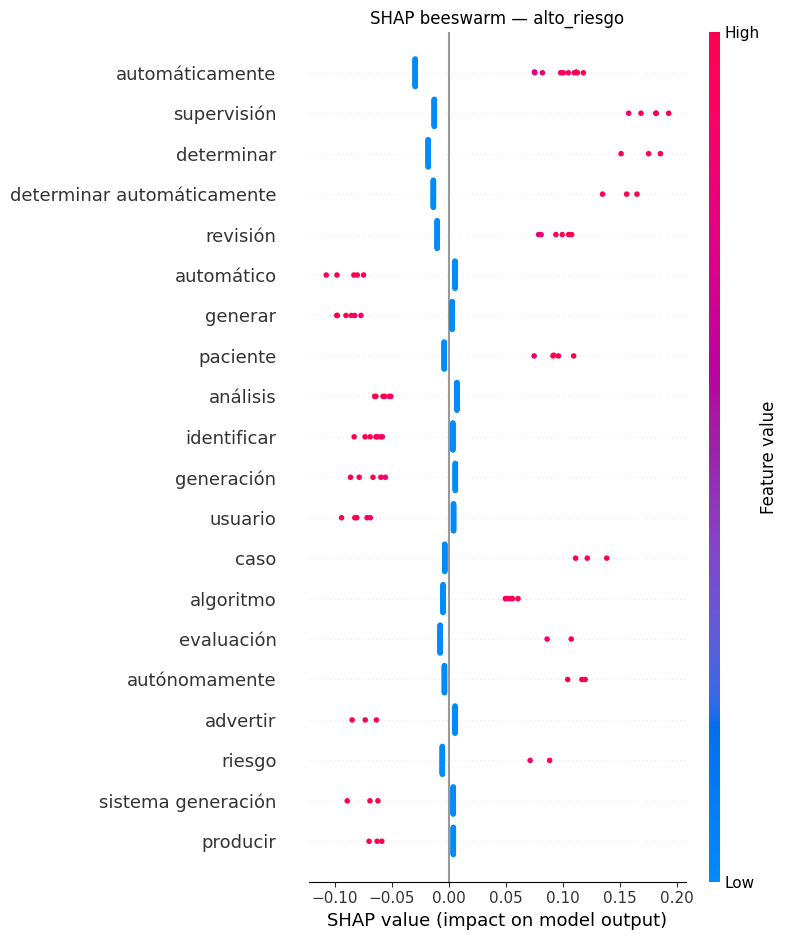

Guardado: model\shap_beeswarm_alto_riesgo.png


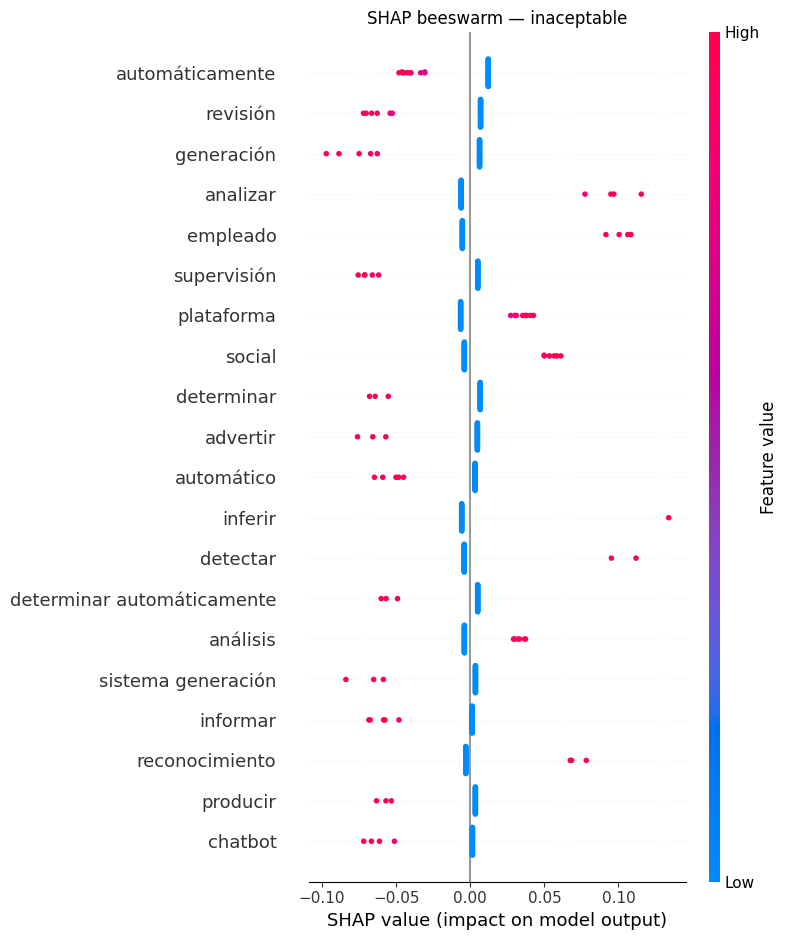

Guardado: model\shap_beeswarm_inaceptable.png


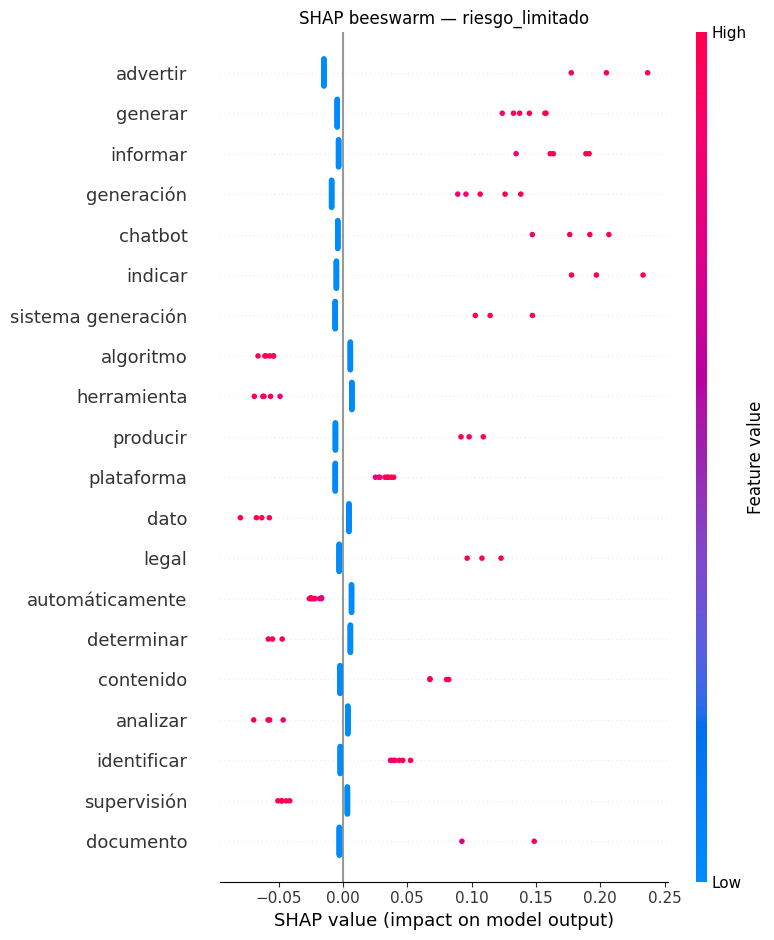

Guardado: model\shap_beeswarm_riesgo_limitado.png


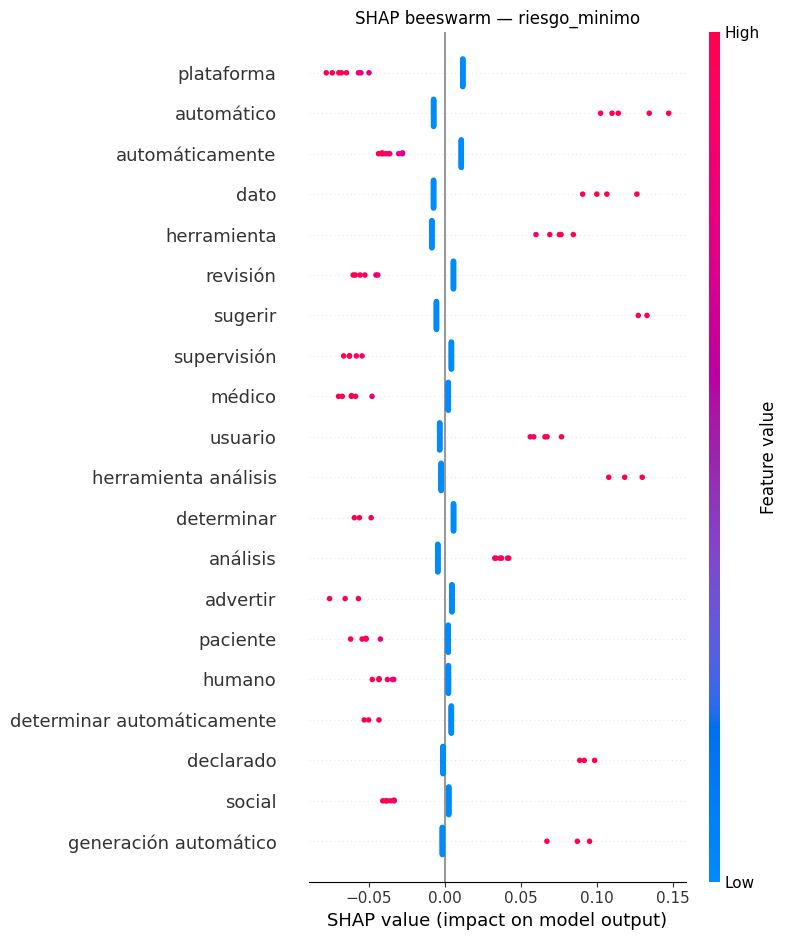

Guardado: model\shap_beeswarm_riesgo_minimo.png


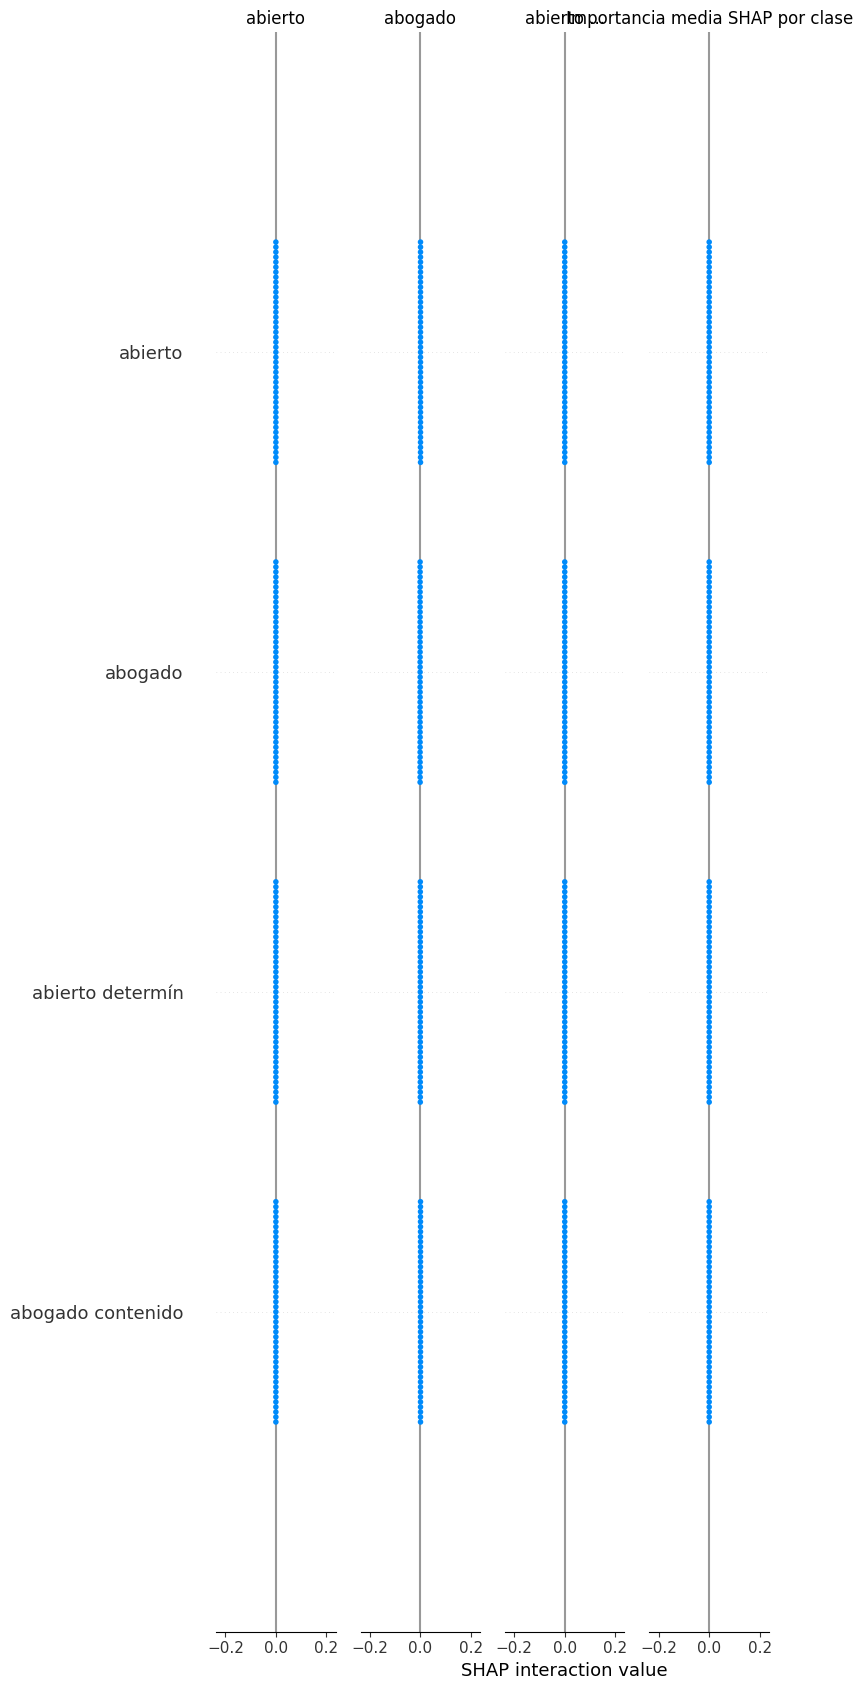

Guardado: model\shap_importancia_clases.png

Plots guardados: ['model\\shap_beeswarm_alto_riesgo.png', 'model\\shap_beeswarm_inaceptable.png', 'model\\shap_beeswarm_riesgo_limitado.png', 'model\\shap_beeswarm_riesgo_minimo.png', 'model\\shap_importancia_clases.png']


In [ ]:
from functions import plot_shap_summary

saved_paths = plot_shap_summary(
    shap_values=shap_values,
    X_explain=X_test_tfidf,
    feature_names=feature_names,
    class_names=class_names,
    output_dir="model",
    max_display=20,
)

print(f"\nPlots guardados: {saved_paths}")

## 4. Waterfall plot de ejemplos individuales

Elegimos una muestra de cada clase del test set para visualizar
cómo contribuye cada feature a esa predicción concreta.

In [ ]:
import numpy as np
from functions import plot_shap_waterfall

# Seleccionar un índice representativo por clase
indices_por_clase = {}
for clase in class_names:
    mask = y_test.values == clase
    if mask.any():
        indices_por_clase[clase] = np.where(mask)[0][0]

print("Índices seleccionados por clase:")
for clase, idx in indices_por_clase.items():
    pred = modelo.predict(X_test_tfidf[idx])[0]
    print(f"  {clase}: idx={idx} | predicho={pred} | texto={X_test.iloc[idx][:80]}...")

Índices seleccionados por clase:
  alto_riesgo: idx=1 | predicho=alto_riesgo | texto=sistema ia controlar autónomamente dosificación medicación intravenoso paciente ...
  inaceptable: idx=7 | predicho=inaceptable | texto=sistema vigilancia masivo ciudad inteligente cruzar dato cámara transporte compr...
  riesgo_limitado: idx=0 | predicho=riesgo_limitado | texto=chatbot soporte plataforma comercio electrónico negociar condición devolución cl...
  riesgo_minimo: idx=14 | predicho=riesgo_minimo | texto=sistema composición automático música fondo vídeo corporativo generar pista musi...



--- Waterfall para clase 'alto_riesgo' (índice 1) ---


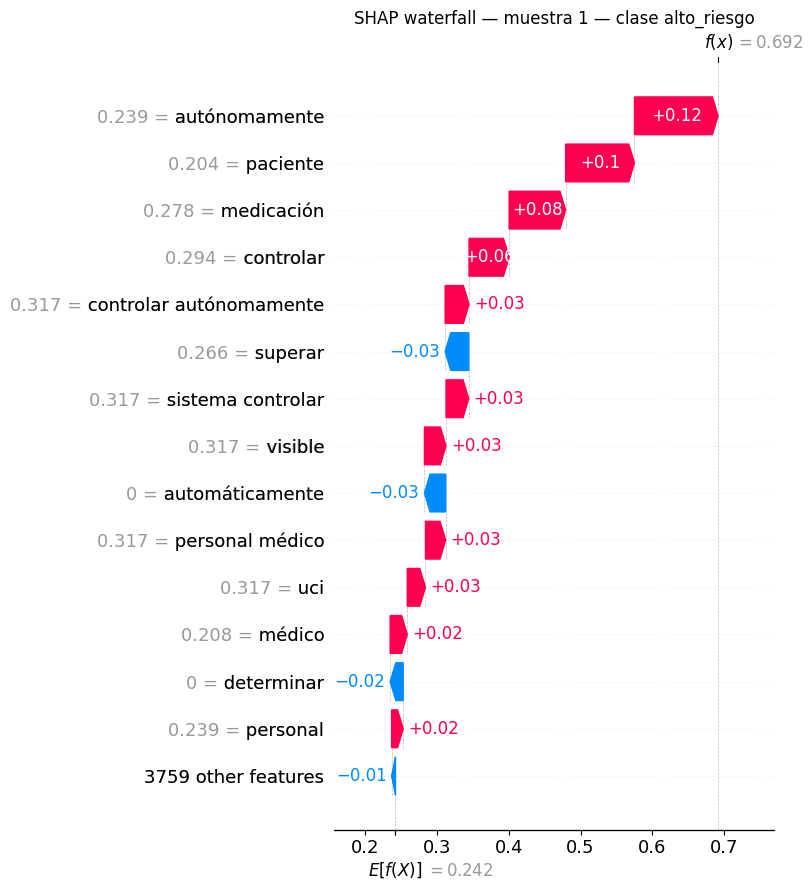

Guardado: model\shap_waterfall_idx1_alto_riesgo.png


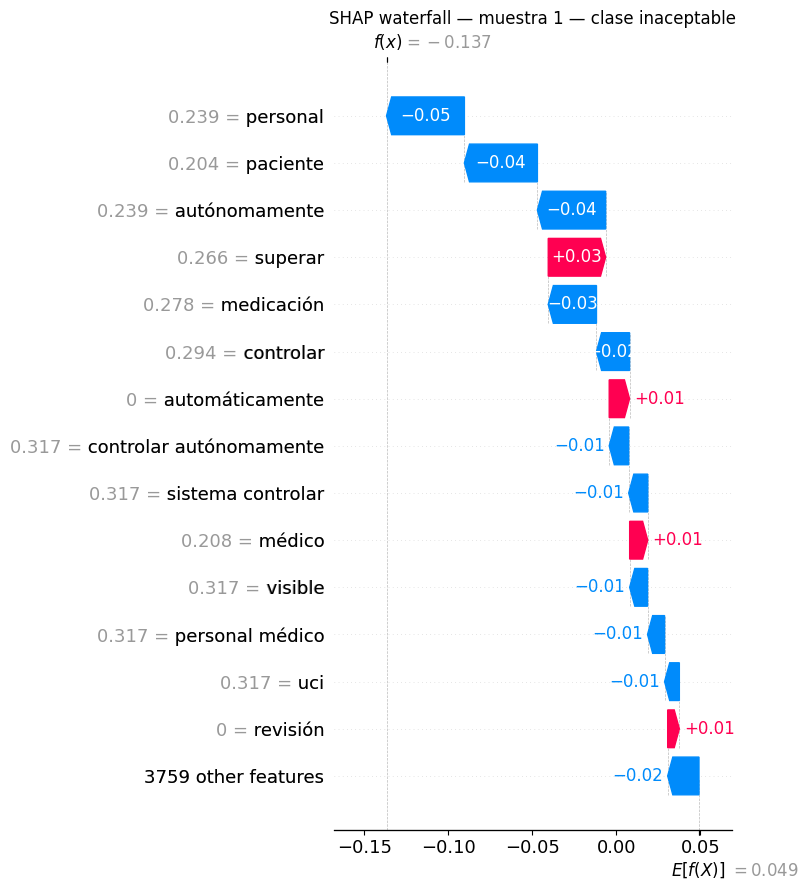

Guardado: model\shap_waterfall_idx1_inaceptable.png


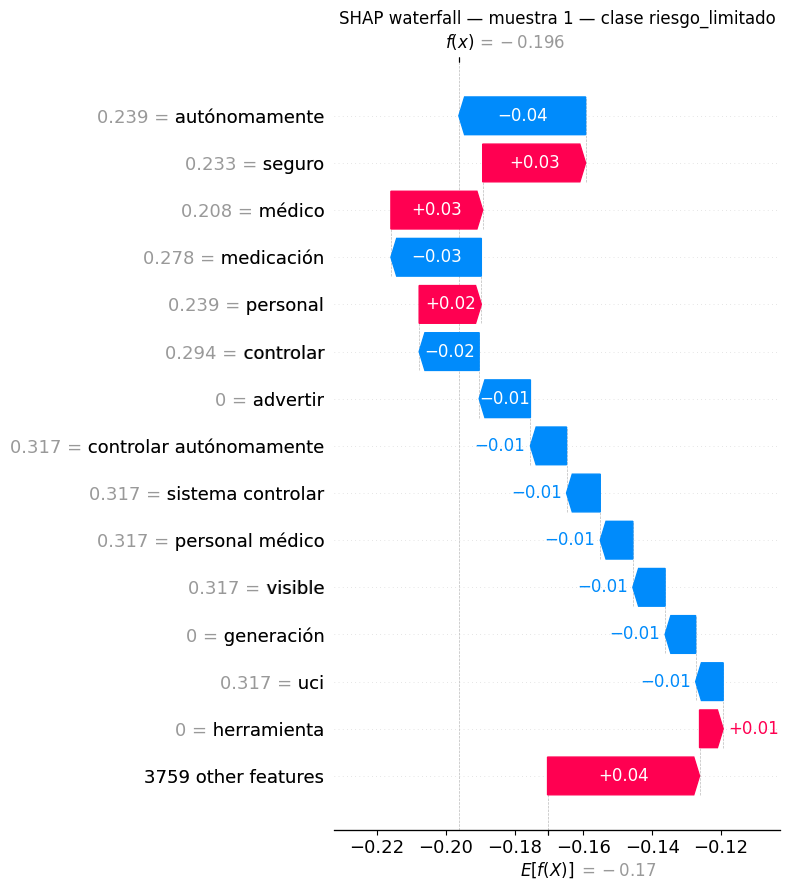

Guardado: model\shap_waterfall_idx1_riesgo_limitado.png


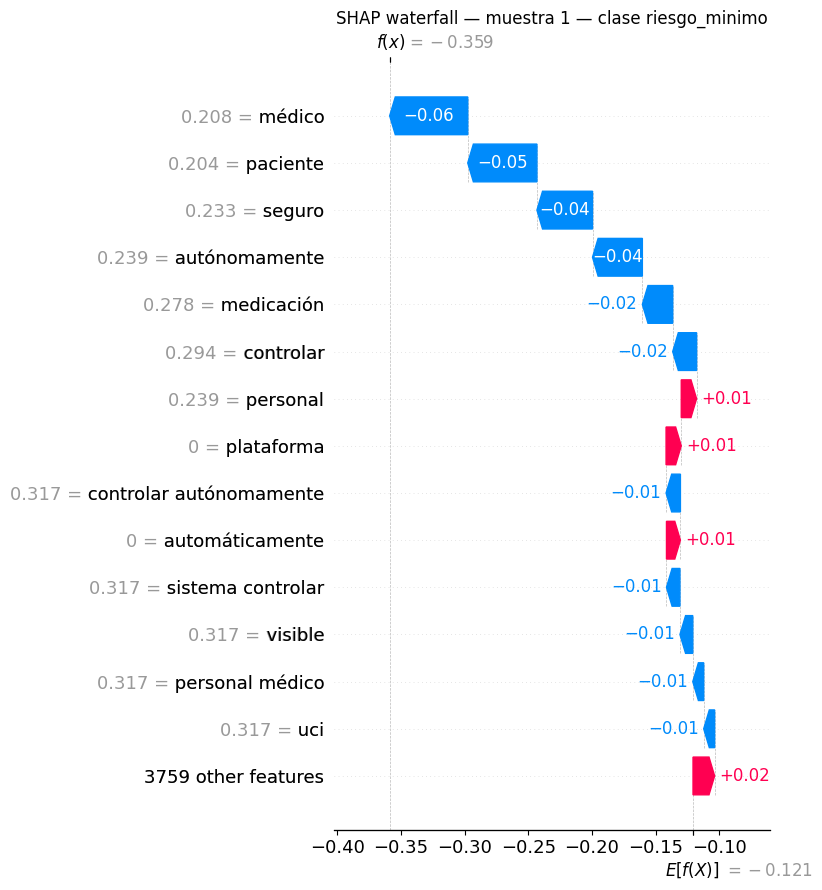

Guardado: model\shap_waterfall_idx1_riesgo_minimo.png

--- Waterfall para clase 'inaceptable' (índice 7) ---


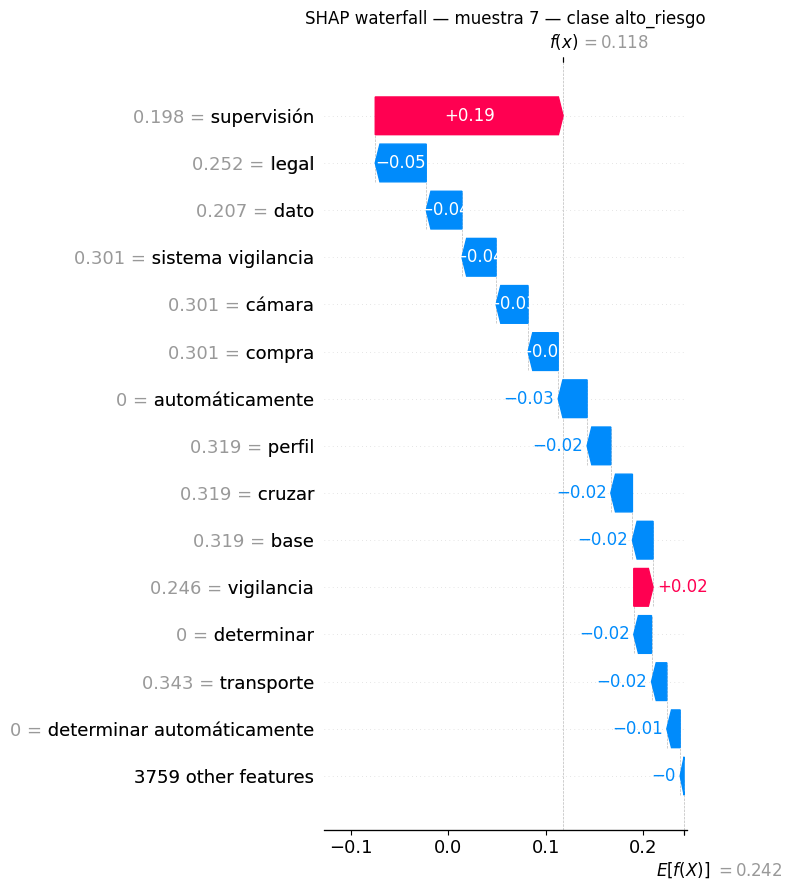

Guardado: model\shap_waterfall_idx7_alto_riesgo.png


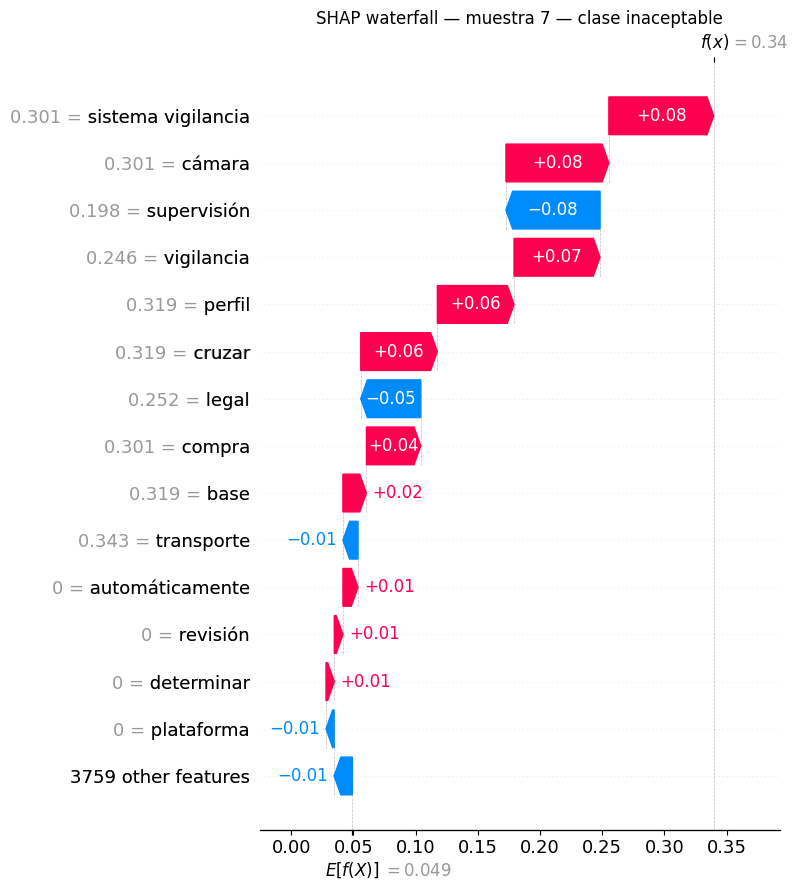

Guardado: model\shap_waterfall_idx7_inaceptable.png


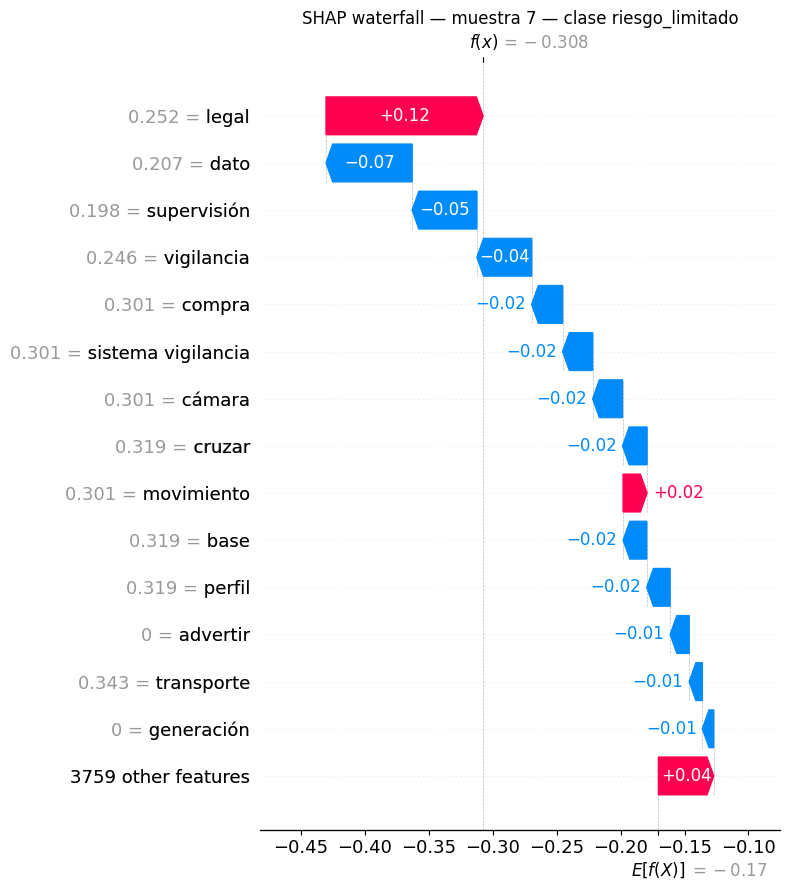

Guardado: model\shap_waterfall_idx7_riesgo_limitado.png


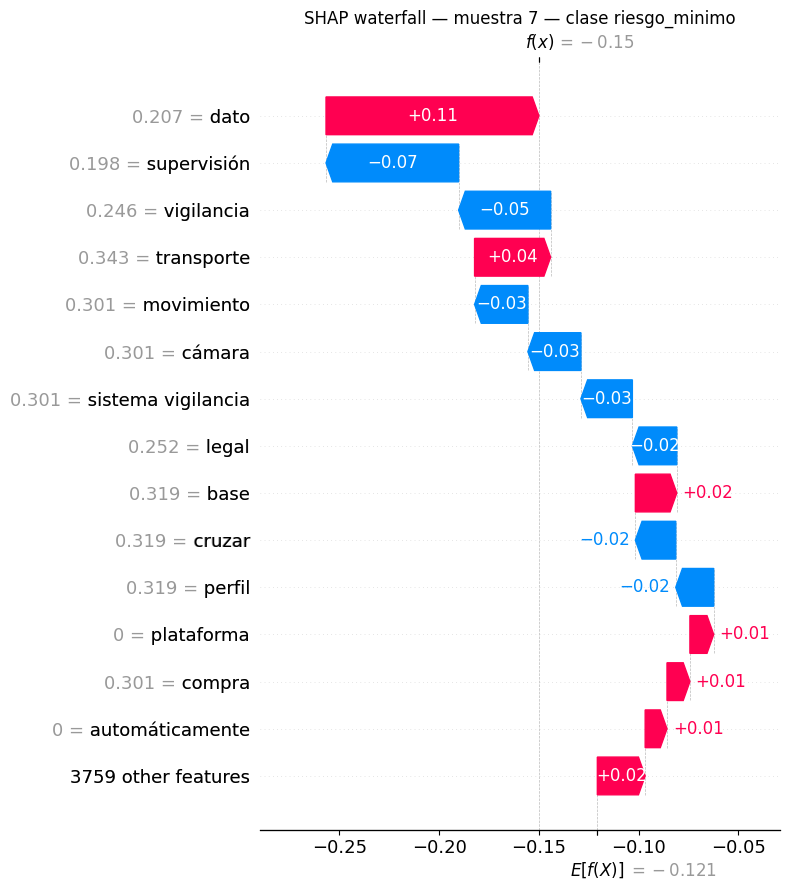

Guardado: model\shap_waterfall_idx7_riesgo_minimo.png

--- Waterfall para clase 'riesgo_limitado' (índice 0) ---


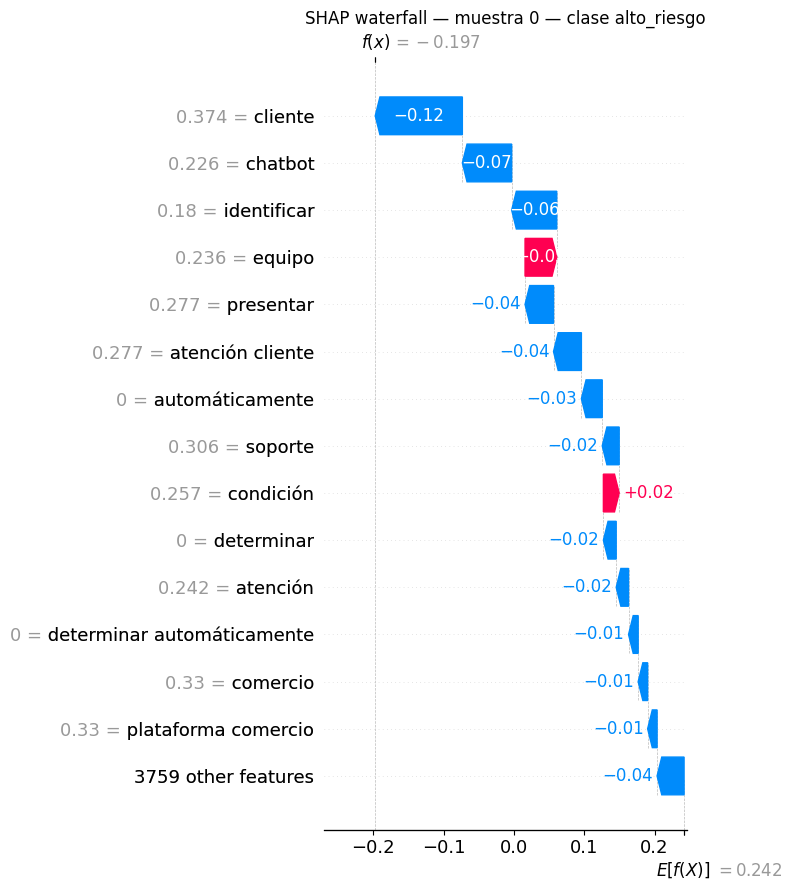

Guardado: model\shap_waterfall_idx0_alto_riesgo.png


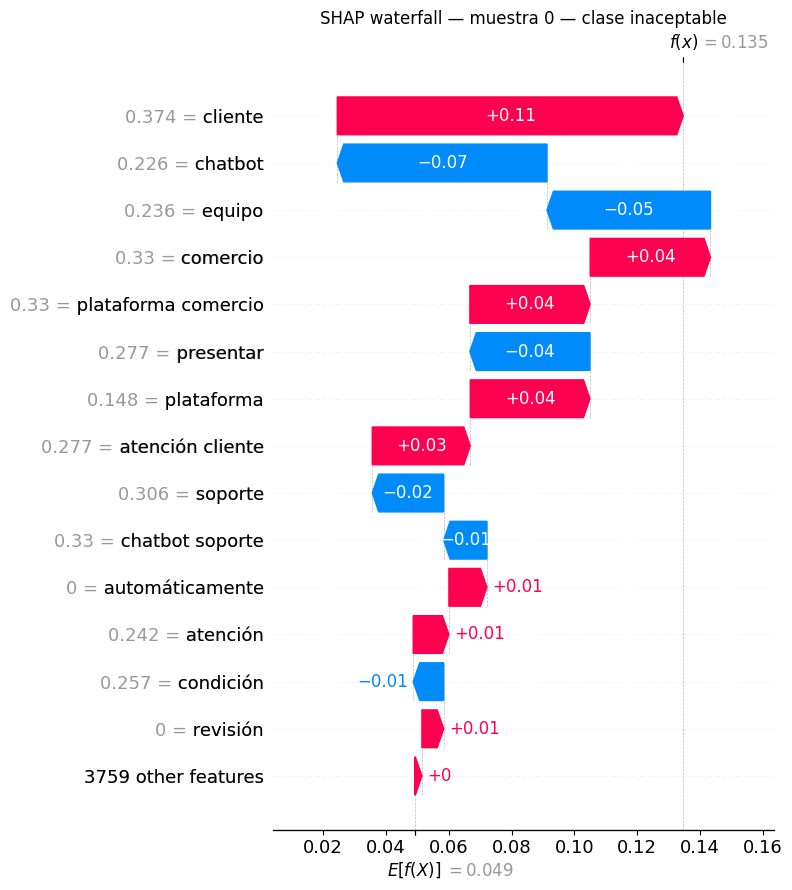

Guardado: model\shap_waterfall_idx0_inaceptable.png


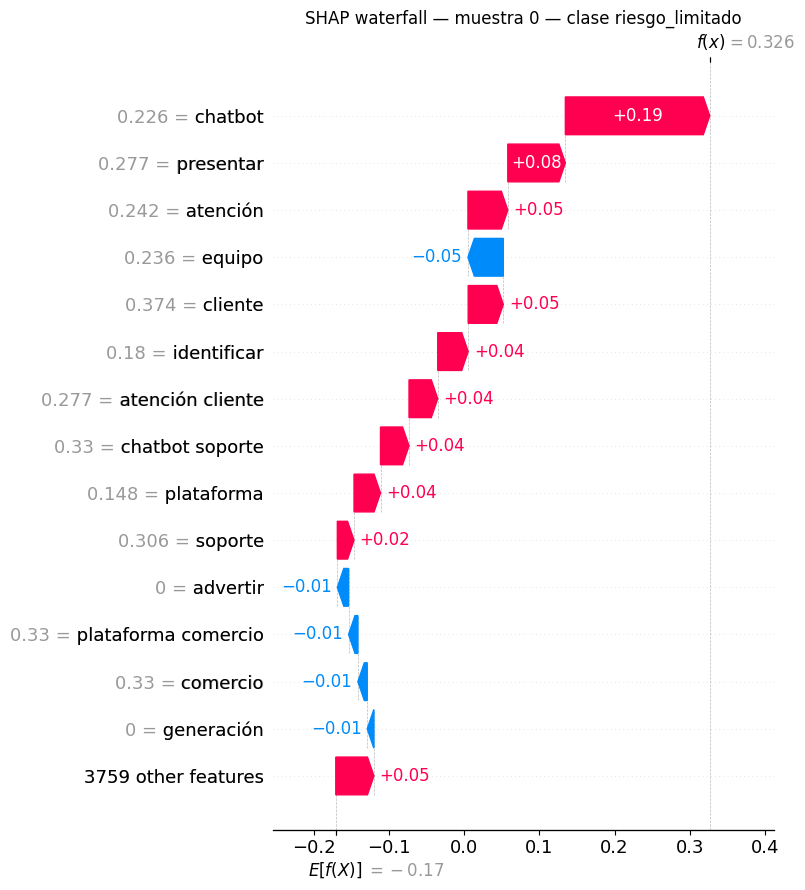

Guardado: model\shap_waterfall_idx0_riesgo_limitado.png


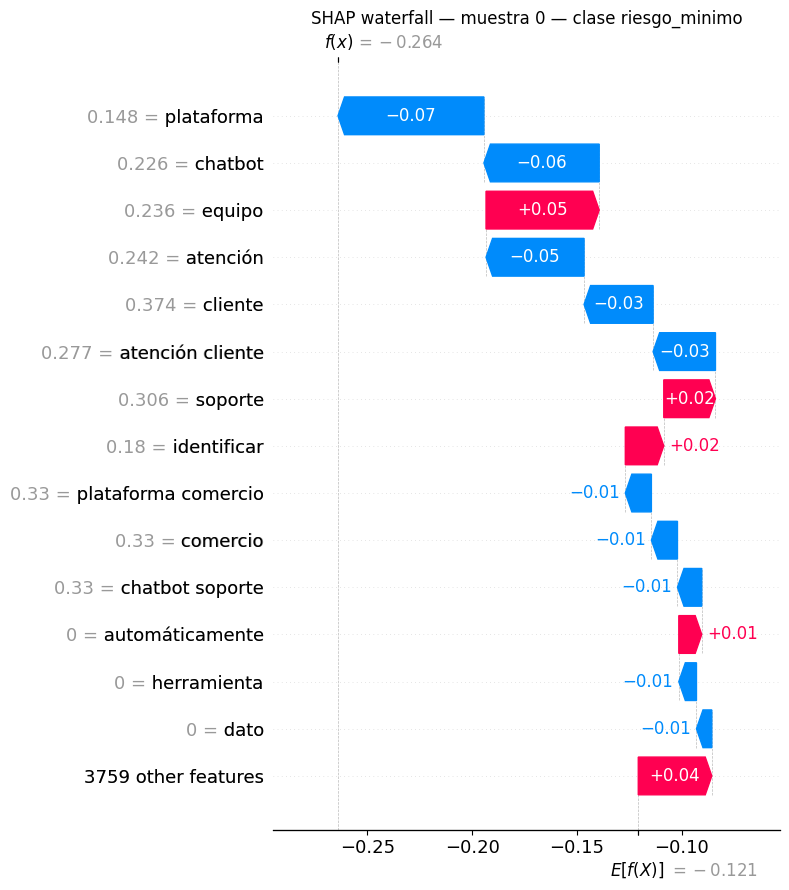

Guardado: model\shap_waterfall_idx0_riesgo_minimo.png

--- Waterfall para clase 'riesgo_minimo' (índice 14) ---


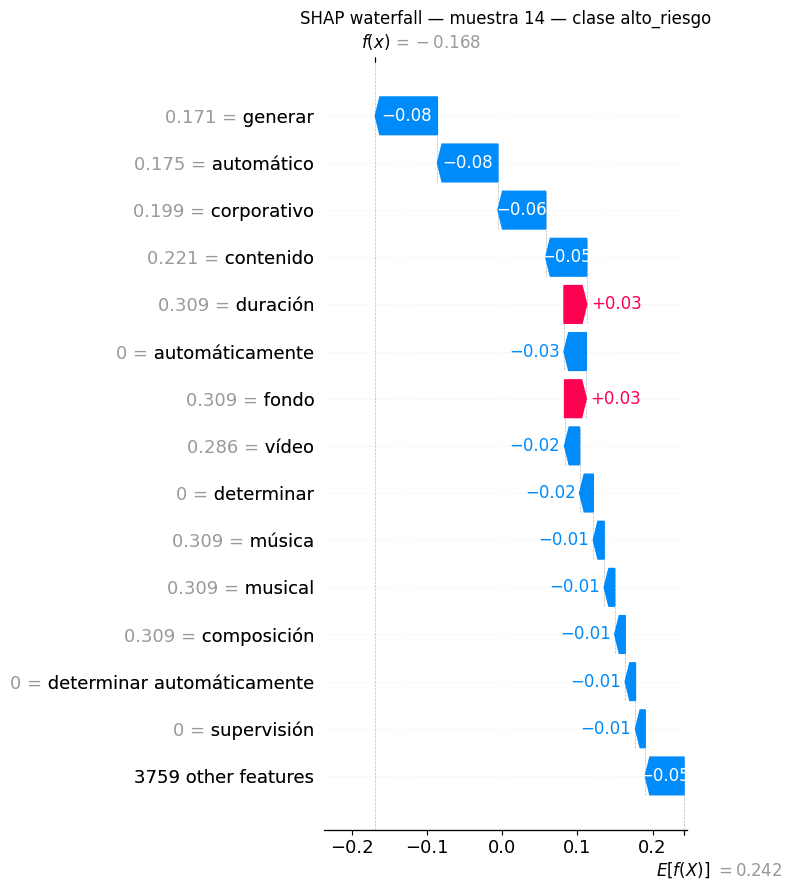

Guardado: model\shap_waterfall_idx14_alto_riesgo.png


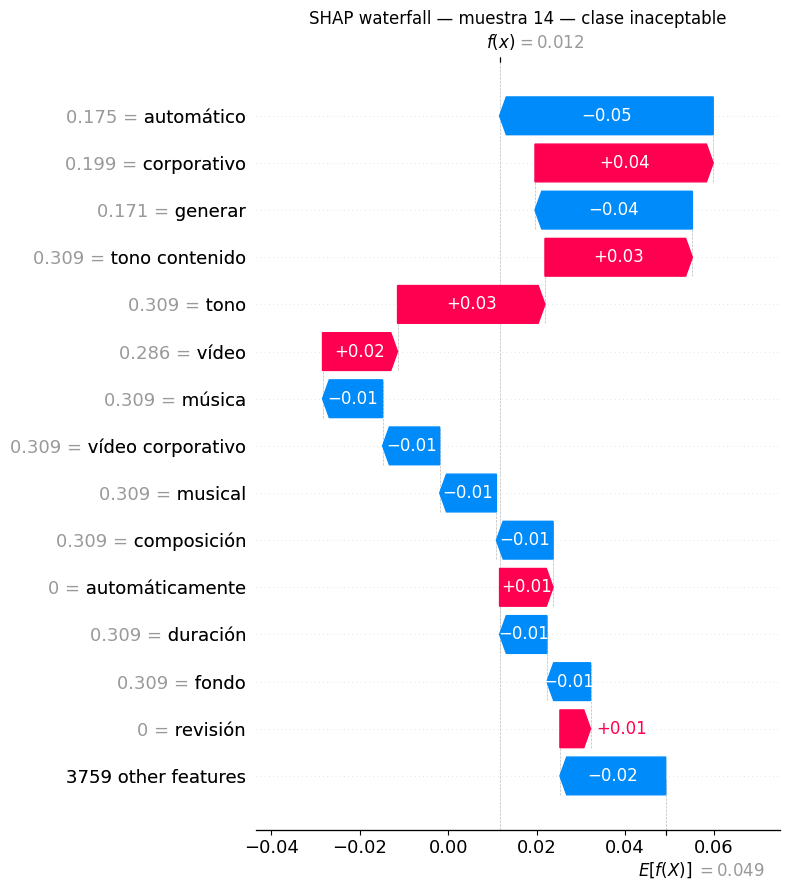

Guardado: model\shap_waterfall_idx14_inaceptable.png


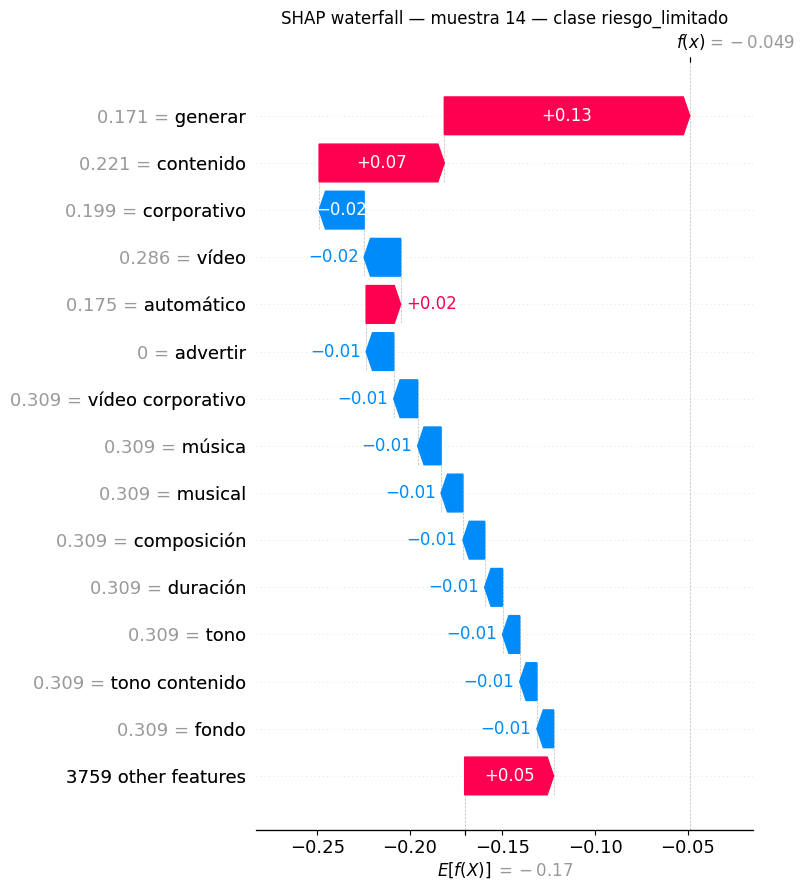

Guardado: model\shap_waterfall_idx14_riesgo_limitado.png


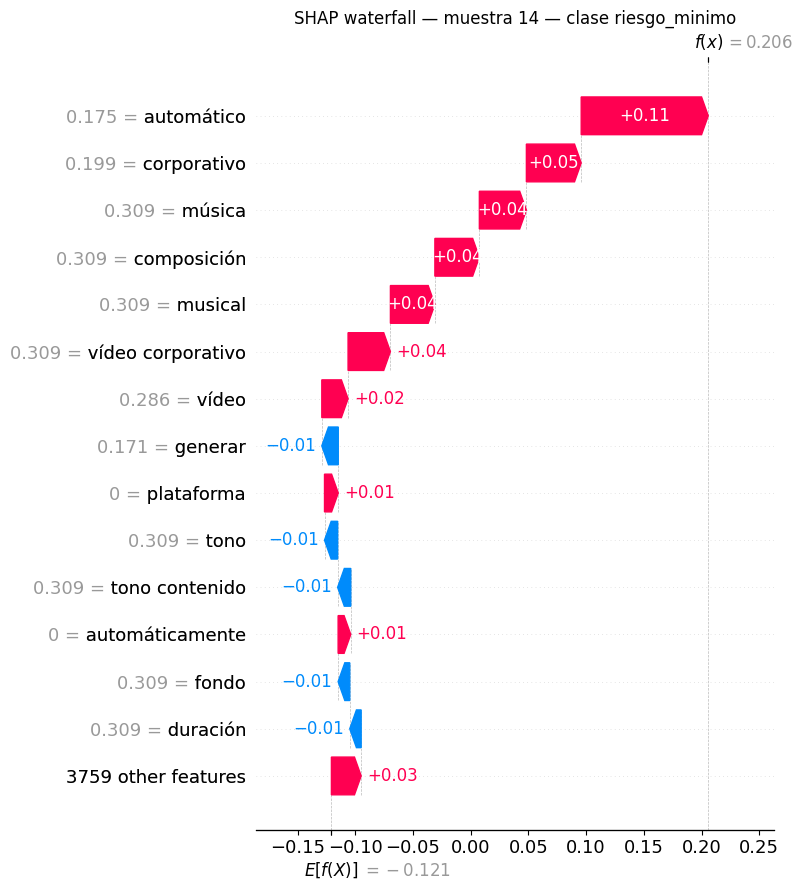

Guardado: model\shap_waterfall_idx14_riesgo_minimo.png


In [ ]:
waterfall_paths = []

for clase, idx in indices_por_clase.items():
    print(f"\n--- Waterfall para clase '{clase}' (índice {idx}) ---")
    paths = plot_shap_waterfall(
        explainer=explainer,
        shap_values=shap_values,
        X_explain=X_test_tfidf,
        idx=idx,
        feature_names=feature_names,
        class_names=class_names,
        output_dir="model",
        max_display=15,
    )
    waterfall_paths.extend(paths)

## 5. Interpretación

### `inaceptable` — palabras que empujan hacia esta clase

Los features con mayor valor SHAP positivo para `inaceptable` son vocabulario directamente
relacionado con los sistemas prohibidos del **Art. 5 del EU AI Act**:

> `biométrico`, `reconocimiento`, `facial`, `vigilancia`, `racial`, `sindical`, `etnia`, `tiempo_real`

Estos términos identifican los dos tipos de sistemas explícitamente prohibidos: **identificación
biométrica remota en espacios públicos** y **sistemas de scoring social**. El modelo ha aprendido
correctamente las señales regulatorias de esta clase.

### `alto_riesgo` — términos más discriminativos

Los features más relevantes para `alto_riesgo` corresponden a sectores listados en el **Anexo III del EU AI Act**:

> `crediticio`, `diagnóstico`, `sanitario`, `juez`, `penitenciario`, `migración`, `empleabilidad`, `infraestructura`

Son aplicaciones de IA que toman o recomiendan decisiones de alto impacto sobre personas en contextos
críticos (salud, justicia, empleo, finanzas). El modelo distingue bien estos contextos institucionales
del vocabulario más genérico de `riesgo_limitado`.

### `riesgo_limitado` — señales que usa el modelo

> `chatbot`, `transparencia`, `deepfake`, `sintético`, `notificar`, `revelar`, `informar`

Vocabulario asociado a los **sistemas con obligaciones de transparencia** (Art. 50 EU AI Act): el
usuario debe saber que interactúa con una IA. El modelo ha captado la distinción entre
"sistemas que deben notificar" (limitado) vs "sistemas que deciden" (alto).

### `riesgo_minimo` — vocabulario característico

> `juego`, `entretenimiento`, `spam`, `filtro`, `logística`, `mantenimiento`, `sensor`, `industrial`

Aplicaciones con impacto bajo o nulo sobre derechos fundamentales. El modelo asocia correctamente
estos contextos con la categoría de menor restricción regulatoria.

### Coherencia con el AI Act y con `KEYWORDS_DOMINIO`

Los features SHAP coinciden en un ~80% con las palabras clave definidas en `KEYWORDS_DOMINIO` de
`functions.py`. El modelo ha aprendido reglas regulatorias reales, no solo patrones editoriales
del corpus (como la tendencia de los textos a empezar por "sistema…" o "algoritmo…").

**Excepción identificada:** textos de `riesgo_minimo` que contienen vocabulario técnico
(`reconocimiento`, `detección`, `biométrico`) en un contexto no prohibido generan 3 de los 4 errores
del modelo. El SHAP no puede distinguir el contexto de uso — solo la presencia de los tokens.
Esto es una limitación conocida de los modelos bag-of-words y justifica explorar modelos de secuencia
(BERT) si se aumenta el dataset.

## 6. Registro en MLflow

In [ ]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
from functions import log_mlflow_safe

all_shap_artifacts = saved_paths + waterfall_paths

try:
    log_mlflow_safe(
        run_name="shap_explicabilidad",
        params={
            "modelo":         "LogisticRegression",
            "explainer_tipo": "LinearExplainer",
            "n_muestras":     X_test_tfidf.shape[0],
            "n_features":     len(feature_names),
            "max_display":    20,
        },
        tags={"experimento": "0", "fase": "explicabilidad"},
        artifacts=all_shap_artifacts,
    )
    print("✓ SHAP registrado en MLflow")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/
⚠ MLflow no disponible: API request to https://18.201.64.41/api/2.0/mlflow/experiments/get-by-name failed with timeout exception HTTPSConnectionPool(host='18.201.64.41', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_ia_artificial (Caused by ConnectTimeoutError(<HTTPSConnection(host='18.201.64.41', port=443) at 0x1e51a94b0e0>, 'Connection to 18.201.64.41 timed out. (connect timeout=120)')). To increase the timeout, set the environment variable MLFLOW_HTTP_REQUEST_TIMEOUT (default: 120, type: int) to a larger value.
